<a href="https://colab.research.google.com/github/evucelic/Diplomski-Projekt/blob/hmm-vae/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
data = pd.read_csv(
    "/content/100_Portfolios_10x10_Daily_valueweighted.csv",
    parse_dates=True,
    low_memory=False
)
data = data.set_index("Date")
data.head()

,SMALL LoBM,ME1 BM2,ME1 BM3,ME1 BM4,ME1 BM5,ME1 BM6,ME1 BM7,ME1 BM8,ME1 BM9,SMALL HiBM,...,BIG LoBM,ME10 BM2,ME10 BM3,ME10 BM4,ME10 BM5,ME10 BM6,ME10 BM7,ME10 BM8,ME10 BM9,BIG HiBM
Date,,,,,,,,,,,,,,,,,,,,,
19260701,-99.99,0.00,-99.99,1.59,-3.08,4.64,2.57,3.81,-0.52,-0.84,...,0.00,1.10,-0.15,-0.03,0.52,0.48,-0.43,-0.08,0.17,-99.99
19260702,-99.99,-0.27,-99.99,0.00,-0.97,-4.10,0.31,-0.47,2.74,-0.27,...,0.31,0.71,0.97,0.57,0.52,0.15,0.63,-0.04,0.34,-99.99
19260706,-99.99,1.01,-99.99,-4.69,2.35,-1.79,0.00,2.44,-5.18,-0.23,...,0.49,-0.19,0.89,0.31,-0.12,-0.18,-0.33,-0.40,-0.34,-99.99
19260707,-99.99,-1.67,-99.99,4.92,0.51,5.27,0.00,-0.74,-0.24,-0.02,...,-0.20,-0.01,0.66,0.38,0.03,0.25,-0.29,0.52,0.17,-99.99
19260708,-99.99,0.00,-99.99,1.56,-0.51,-1.06,0.00,4.90,0.45,0.26,...,0.56,-0.12,0.35,0.55,-0.14,0.19,-0.12,0.54,0.51,-99.99


In [23]:
data= data.replace(-99.99, np.nan)
data = data.replace(-999, np.nan)
data = data / 100.0
data = data.clip(lower=-0.9999)
data = np.log1p(data)
data = data.fillna(0.0)
data = data.astype(np.float32)
data.index = pd.to_datetime(data.index, format="%Y%m%d")

In [24]:
print(data.min().min(), data.max().max())
print(data.describe(percentiles=[0.001, 0.01, 0.99, 0.999]).T.sort_values("min").head(5))
print(data.info())

-9.21034049987793 1.0856958627700806
           count      mean       std       min      0.1%        1%     50%  \
ME1 BM2  26110.0 -0.000119  0.065895 -9.210340 -0.248218 -0.076881  0.0000   
ME2 BM3  26110.0 -0.000222  0.064542 -9.210340 -0.223144 -0.076989  0.0000   
ME1 BM6  26110.0  0.000366  0.023704 -1.091537 -0.177295 -0.065276  0.0003   
ME1 BM5  26110.0  0.000214  0.027429 -1.011701 -0.223144 -0.069029  0.0000   
ME1 BM4  26110.0  0.000315  0.025712 -0.753747 -0.182362 -0.070091  0.0000   

              99%     99.9%       max  
ME1 BM2  0.081756  0.287657  1.085696  
ME2 BM3  0.075723  0.261666  0.693147  
ME1 BM6  0.066724  0.171850  0.445327  
ME1 BM5  0.071458  0.223144  0.587787  
ME1 BM4  0.074087  0.194283  0.567981  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26110 entries, 1926-07-01 to 2025-10-31
Data columns (total 100 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SMALL LoBM  26110 non-null  float32
 1  

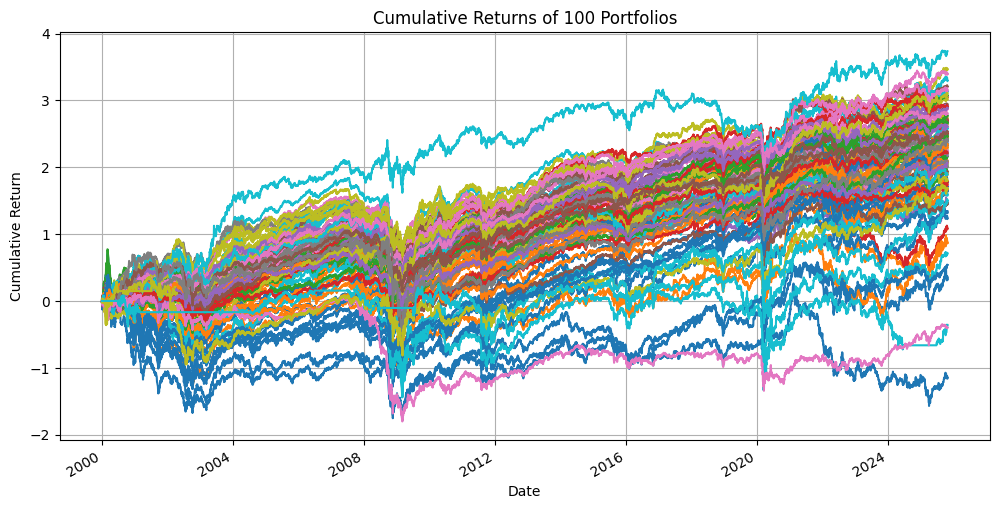

In [25]:
cum_returns = (data.loc[data.index > "2000-01-01"]).cumsum()
cum_returns.plot(figsize=(12, 6))
plt.title("Cumulative Returns of 100 Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid()
plt.legend().set_visible(False)
plt.show()

Podaci od 02.07.1945 - 31.10.2025. Podaci koji nedostaju su zamijenjeni s 0 (stacionarni trenutci)

Portfelji su formirani na temelju 2 karakteristike, size(market equity) i value (Book-to-market)

Napomena za size:
"A fundamental problem in handling accounting data is the look-ahead bias; we must not include data in forming a portfolio that was not available knowledge at the time. Of course, researchers have more information when looking into the past than agents actually had at that moment. However, abnormal excess returns from a trading strategy should not rely on an information advantage because the differential cannot be the result of informed agents’ trades. Hence, we have to lag accounting information.

We continue to lag market capitalization and firm size by one month" source: https://www.tidy-finance.org/r/value-and-bivariate-sorts.html



Kako su točno formirani portfelji?
U danom trenutku t, uzimamo cijeli universe dionica u tom trenutku i pridružimo im dvije karakteristike npr. size i value.
Recimo da svakoj dionici pridružimo size od 1-10 i value od 1-10. Vrijednosti 1-10 predstavljaju decile veličine/value s NYSE burze, računaju se jednom godišnje te su stacionarni godinu dana.

Grupiramo dionice na temelju labela i formiramo 10x10 = 100 portfelja u svakom trenutku, weightanih proporcionalno market capu (lagganom 1mj).

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.distributions import Normal, StudentT

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

![image](https://github.com/evucelic/Diplomski-Projekt/blob/hmm-vae/images/1-s2.0-S0020025525003160-gr001.jpg?raw=1)

In [27]:
# TODO MLP za duzi forcasting unaprijed
# class MLP(nn.Module):
#     """
#     Learn VAR(1) dynamics: p(z_t | z_{t-1}).
#     """
#     def __init__(self, z_dim, hidden_dim):
#         super().__init__()
#         self.fc1 = nn.Linear(z_dim, hidden_dim)
#         self.fc_mu = nn.Linear(hidden_dim, z_dim)
#         self.fc_logvar = nn.Linear(hidden_dim, z_dim)

#     def forward(self, z_prev):
#         h = F.relu(self.fc1(z_prev))
#         mu = self.fc_mu(h)
#         logvar = self.fc_logvar(h)
#         return mu, logvar

In [28]:
# https://stats.stackexchange.com/questions/60680/kl-divergence-between-two-multivariate-gaussians
# TODO https://www.microsoft.com/en-us/research/blog/less-pain-more-gain-a-simple-method-for-vae-training-with-less-of-that-kl-vanishing-agony/

In [29]:
class FinancialDataset(Dataset):
    def __init__(self, returns_matrix, t_past=60, t_future=20):
        if isinstance(returns_matrix, np.ndarray):
            self.data = torch.from_numpy(returns_matrix).float()
        else:
            self.data = torch.tensor(returns_matrix, dtype=torch.float32)

        self.t_past = t_past
        self.t_future = t_future

    def __len__(self):
        return len(self.data) - (self.t_past + self.t_future) + 1

    def __getitem__(self, idx):
        start_idx = idx
        split_idx = idx + self.t_past
        end_idx = split_idx + self.t_future

        x_past = self.data[start_idx : split_idx]      # (60, 100)
        x_future = self.data[split_idx : end_idx]      # (20, 100)

        return x_past, x_future


In [30]:
def make_positive_df(df_raw, min_df=2.05):
    return F.softplus(df_raw) + min_df

def make_positive_scale(raw_scale, min_scale=1e-4):
    return F.softplus(raw_scale) + min_scale

class CVAE(nn.Module):
    def __init__(self, n_assets=100, t_past=60, t_future=20, z_dim=10):
        super().__init__()
        self.t_past = t_past
        self.t_future = t_future
        self.n_assets = n_assets
        self.z_dim = z_dim

        # -------- ENCODER (posterior q(z|past,future)) --------
        input_dim = (t_future + t_past) * n_assets
        self.enc_fc1 = nn.Linear(input_dim, 512)
        self.enc_mu = nn.Linear(512, z_dim)
        self.enc_logscale = nn.Linear(512, z_dim)
        self.enc_df_raw = nn.Linear(512, 1)

        # -------- CONDITION ENCODER --------
        cond_input_dim = t_past * n_assets
        self.cond_fc = nn.Linear(cond_input_dim, 32)

        # -------- CONDITIONAL PRIOR p(z|past) --------
        self.prior_fc1 = nn.Linear(cond_input_dim, 256)
        self.prior_mu = nn.Linear(256, z_dim)
        self.prior_logscale = nn.Linear(256, z_dim)
        self.prior_df_raw = nn.Linear(256, 1)

        # -------- DECODER --------
        dec_input_dim = z_dim + 32
        self.dec_fc1 = nn.Linear(dec_input_dim, 512)
        self.dec_out = nn.Linear(512, t_future * n_assets * 2)  # mu + logsigma

    # q(z | past, future)
    def encode(self, x_past, x_future):
        flat_past = x_past.flatten(start_dim=1)
        flat_future = x_future.flatten(start_dim=1)

        x_full = torch.cat([flat_past, flat_future], dim=1)
        h = F.relu(self.enc_fc1(x_full))

        mu = self.enc_mu(h)                           # (B, z_dim)
        scale = make_positive_scale(self.enc_logscale(h))
        df = make_positive_df(self.enc_df_raw(h))     # (B, 1)

        df = df.expand_as(mu)
        q_dist = StudentT(df=df, loc=mu, scale=scale) # used for rsample (reparametrization trick)
        return q_dist, (mu, scale, df)

    # p(z | past)  (conditional prior)
    # used for KL divergence between the posterior and conditional prior
    # used for sampling at generation time when we don't have future
    def prior(self, x_past):
        flat_past = x_past.flatten(start_dim=1)
        h = F.relu(self.prior_fc1(flat_past))

        mu = self.prior_mu(h)                         # (B, z_dim)
        scale = make_positive_scale(self.prior_logscale(h))
        df = make_positive_df(self.prior_df_raw(h))   # (B, 1)

        df = df.expand_as(mu)
        p_dist = StudentT(df=df, loc=mu, scale=scale) # used for rsample also
        return p_dist, (mu, scale, df)

    # p(x_future | z, past)
    # maps latents + condition input back to data space, returns parameters of the distribution
    def decode(self, z, x_past):
        flat_past = x_past.flatten(start_dim=1)
        cond_summary = F.relu(self.cond_fc(flat_past))

        decoder_input = torch.cat([z, cond_summary], dim=1)
        h = F.relu(self.dec_fc1(decoder_input))
        flat_out = self.dec_out(h)

        reshaped = flat_out.view(-1, self.t_future, self.n_assets, 2)
        recon_mu = reshaped[:, :, :, 0]
        recon_logsigma = reshaped[:, :, :, 1]
        return recon_mu, recon_logsigma

    def forward(self, x_past, x_future):
        # posterior
        qz, (q_mu, q_scale, q_df) = self.encode(x_past, x_future)
        z = qz.rsample()  # reparameterized Student t sample

        # conditional prior
        pz, (p_mu, p_scale, p_df) = self.prior(x_past)

        # decoder
        recon_mu, recon_logsigma = self.decode(z, x_past)

        return {
            "recon_mu": recon_mu,
            "recon_logsigma": recon_logsigma,
            "z": z,
            "qz": qz, "pz": pz,
            "q_params": (q_mu, q_scale, q_df),
            "p_params": (p_mu, p_scale, p_df),
        }


In [31]:
# https://huggingface.co/blog/NormalUhr/kl-divergence-estimator-rl-llm
# http://joschu.net/blog/kl-approx.html
# schulman estimator
def kld_k3_per_item(q_dist, p_dist, n_samples=128):
    # z ~ q
    z = q_dist.rsample((n_samples,))              # (S,B,10)
    logq = q_dist.log_prob(z).sum(dim=-1)
    logp = p_dist.log_prob(z).sum(dim=-1)

    logr = logp - logq
    r = torch.exp(logr)
    k = (r - 1.0) - logr

    return k.mean(dim=0)                          # (B,)


In [32]:
def recon_loss_student_t(x_future, recon_mu, recon_logsigma, df_data=4.0, eps=1e-4):
    scale = F.softplus(recon_logsigma) + eps
    dist = StudentT(df=df_data, loc=recon_mu, scale=scale)
    nll_per_item = -dist.log_prob(x_future).sum(dim=(1,2))  # sum over (T, N) -> (B,)
    return nll_per_item


In [33]:
def loss_function(x_future,
                  recon_mu, recon_logsigma,
                  q_dist, p_dist,
                  df_data=4.0, beta=1.0,
                  kl_samples=1000):
    recon_per_item = recon_loss_student_t(
        x_future, recon_mu, recon_logsigma, df_data=df_data
    )                                               # (B,)

    # per-item KL(q||p)
    kl_per_item = kld_k3_per_item(q_dist, p_dist, n_samples=kl_samples)  # (B,)

    total_loss = (recon_per_item + beta * kl_per_item).mean()
    return total_loss, recon_per_item.mean(), kl_per_item.mean()


In [34]:
# --- HYPERPARAMETERS ---
EPOCHS = 100
BATCH_SIZE = 128
T_PAST = 60
T_FUTURE = 20
GAP = T_FUTURE

DF_DATA = 4.0
KL_SAMPLES = 1000

# Cyclical Beta Schedule
TARGET_BETA = 1.0
CYCLES = 4
R_PROP = 0.5  # 50% ramp up, 50% plateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- DATA PREP ---
split_idx = int(len(data) * 0.8)
train_data = data.iloc[:split_idx].values
test_data = data.iloc[split_idx + GAP:].values

train_dataset = FinancialDataset(train_data, t_past=T_PAST, t_future=T_FUTURE)
test_dataset = FinancialDataset(test_data, t_past=T_PAST, t_future=T_FUTURE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# --- MODEL SETUP ---
model = CVAE(n_assets=100, t_past=T_PAST, t_future=T_FUTURE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

steps_per_epoch = len(train_loader)
total_steps = EPOCHS * steps_per_epoch
cycle_steps = max(1, total_steps // CYCLES)

def get_current_beta(global_step, cycle_steps, r_prop, target_beta):
    cycle_progress = (global_step % cycle_steps) / cycle_steps
    if cycle_progress < r_prop:
        return target_beta * (cycle_progress / r_prop)
    return target_beta

print(f"Starting training on {len(train_loader.dataset)} samples.")
print(f"Annealing: {CYCLES} cycles of {cycle_steps} steps each.")
print("Starting VAE Training...")

global_step = 0

for epoch in range(EPOCHS):
    # --- TRAIN ---
    model.train()
    train_loss_accum = 0.0
    train_recon_accum = 0.0
    train_kld_accum = 0.0

    for past, future in train_loader:
        past, future = past.to(device), future.to(device)

        current_beta = get_current_beta(global_step, cycle_steps, R_PROP, TARGET_BETA)
        global_step += 1

        result = model(past, future)
        recon_mu = result["recon_mu"]
        recon_logsigma = result["recon_logsigma"]
        qz = result["qz"]
        pz = result["pz"]

        loss, recon, kld = loss_function(
            x_future=future,
            recon_mu=recon_mu,
            recon_logsigma=recon_logsigma,
            q_dist=qz,
            p_dist=pz,
            df_data=DF_DATA,
            beta=current_beta,
            kl_samples=KL_SAMPLES,
        )

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_accum += loss.item()
        train_recon_accum += recon.item()
        train_kld_accum += kld.item()

    avg_train_loss = train_loss_accum / len(train_loader)   # per-batch average
    avg_train_recon = train_recon_accum / len(train_loader)
    avg_train_kld = train_kld_accum / len(train_loader)

    # --- EVAL ---
    model.eval()
    test_loss_accum = 0.0
    test_recon_accum = 0.0
    test_kld_accum = 0.0

    beta_eval = TARGET_BETA # not current beta, for simplicity

    with torch.no_grad():
        for past, future in test_loader:
            past, future = past.to(device), future.to(device)

            result = model(past, future)
            recon_mu = result["recon_mu"]
            recon_logsigma = result["recon_logsigma"]
            qz = result["qz"]
            pz = result["pz"]

            t_loss, t_recon, t_kld = loss_function(
                x_future=future,
                recon_mu=recon_mu,
                recon_logsigma=recon_logsigma,
                q_dist=qz,
                p_dist=pz,
                df_data=DF_DATA,
                beta=beta_eval,
                kl_samples=KL_SAMPLES,
            )

            test_loss_accum += t_loss.item()
            test_recon_accum += t_recon.item()
            test_kld_accum += t_kld.item()

    avg_test_loss = test_loss_accum / len(test_loader)
    avg_test_recon = test_recon_accum / len(test_loader)
    avg_test_kld = test_kld_accum / len(test_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
    print(f"   Breakdown -> "
          f"Train Recon: {avg_train_recon:.4f} | Train KLD: {avg_train_kld:.4f} | Beta(train): {current_beta:.4f}")
    print(f"              "
          f"Test  Recon: {avg_test_recon:.4f} | Test  KLD: {avg_test_kld:.4f} | Beta(test):  {beta_eval:.4f}")


Starting training on 20809 samples.
Annealing: 4 cycles of 4075 steps each.
Starting VAE Training...
Epoch 1/100 | Train Loss: -2516.5964 | Test Loss: -4941.5163
   Breakdown -> Train Recon: -2516.6298 | Train KLD: 0.6331 | Beta(train): 0.0795
              Test  Recon: -4942.6635 | Test  KLD: 1.1472 | Beta(test):  1.0000
Epoch 2/100 | Train Loss: -5345.1989 | Test Loss: -5330.6356
   Breakdown -> Train Recon: -5345.4779 | Train KLD: 2.2630 | Beta(train): 0.1595
              Test  Recon: -5332.9922 | Test  KLD: 2.3567 | Beta(test):  1.0000
Epoch 3/100 | Train Loss: -5576.3236 | Test Loss: -5525.0620
   Breakdown -> Train Recon: -5577.0960 | Train KLD: 3.8006 | Beta(train): 0.2395
              Test  Recon: -5531.5500 | Test  KLD: 6.4880 | Beta(test):  1.0000
Epoch 4/100 | Train Loss: -5743.2310 | Test Loss: -5644.1259
   Breakdown -> Train Recon: -5745.5373 | Train KLD: 8.0966 | Beta(train): 0.3195
              Test  Recon: -5657.8847 | Test  KLD: 13.7588 | Beta(test):  1.0000
Epoch 

In [35]:
def get_latents(model, dataloader):
    model.eval()
    all_mu = []
    with torch.no_grad():
        for past, future in dataloader:
            past, future = past.to(device), future.to(device)

            q_dist, (mu, scale, df) = model.encode(past, future)
            all_mu.append(mu.detach().cpu())

    return torch.cat(all_mu, dim=0)

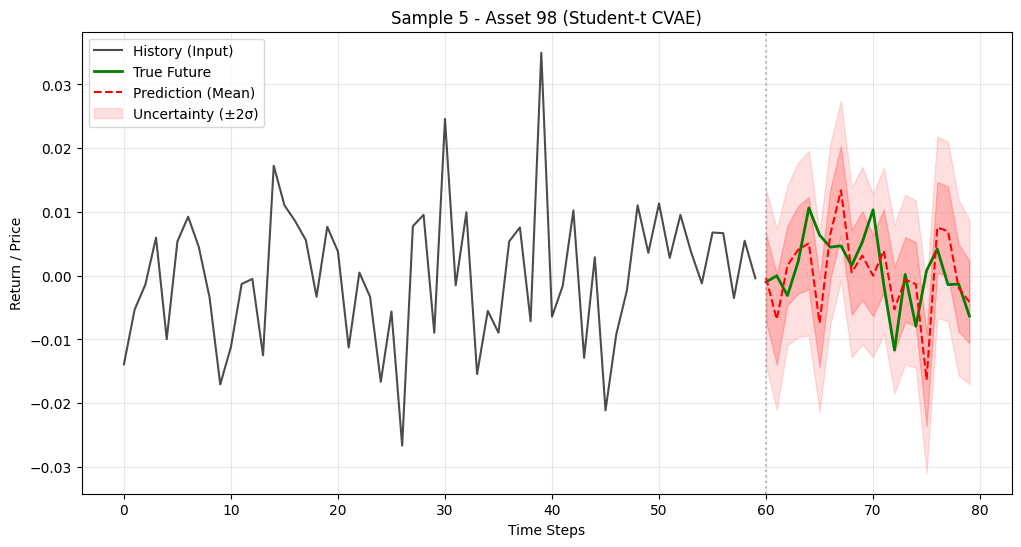

In [36]:
def plot_prediction(model, dataset, sample_idx=0, asset_idx=0, device=None):
    model.eval()
    device = device or next(model.parameters()).device

    past_tensor, future_tensor = dataset[sample_idx]
    past = past_tensor.unsqueeze(0).to(device)      # (1, 60, 100)
    future = future_tensor.unsqueeze(0).to(device)  # (1, 20, 100)

    with torch.no_grad():
        result = model(past, future)
        recon_mu = result["recon_mu"]               # (1, 20, 100)
        recon_logsigma = result["recon_logsigma"]   # (1, 20, 100)

    history = past_tensor[:, asset_idx].cpu().numpy()       # (60,)
    true_future = future_tensor[:, asset_idx].cpu().numpy() # (20,)

    pred_mu = recon_mu.squeeze(0)[:, asset_idx].detach().cpu().numpy()  # (20,)

    pred_sigma = (F.softplus(recon_logsigma) + 1e-4).squeeze(0)[:, asset_idx].detach().cpu().numpy()

    t_history = range(0, len(history))
    t_future = range(len(history), len(history) + len(true_future))

    plt.figure(figsize=(12, 6))
    plt.plot(t_history, history, label="History (Input)", color="black", alpha=0.7)
    plt.plot(t_future, true_future, label="True Future", color="green", linewidth=2)
    plt.plot(t_future, pred_mu, label="Prediction (Mean)", color="red", linestyle="--")

    plt.fill_between(
        t_future,
        pred_mu - 2 * pred_sigma,
        pred_mu + 2 * pred_sigma,
        color="red", alpha=0.12, label="Uncertainty (±2σ)"
    )
    plt.fill_between(
        t_future,
        pred_mu - pred_sigma,
        pred_mu + pred_sigma,
        color="red", alpha=0.20
    )

    plt.title(f"Sample {sample_idx} - Asset {asset_idx} (Student-t CVAE)")
    plt.axvline(x=len(history), color="gray", linestyle=":", alpha=0.5)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.xlabel("Time Steps")
    plt.ylabel("Return / Price")
    plt.show()

plot_prediction(model, test_dataset, sample_idx=5, asset_idx=98)


In [37]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 12.2 MB/s eta 0:00:00


In [38]:
from hmmlearn.hmm import GaussianHMM
from sklearn.utils import check_random_state
from collections import defaultdict


In [39]:
import warnings

def evaluate_hmm(latents, rs, ns, loop):
    aic = []
    bic = []
    lls = []
    convergence_status = []
    iterations = []
    models = defaultdict(list)
    best_models = {}

    X = latents
    lengths = [len(X)]

    for n in ns:
      # transition matrix prior
      transmat_prior = np.full((n,n), 1.05) # assume every transition is possible
      np.fill_diagonal(transmat_prior, 15.0) # assume regimes are persistent

      models[n] = []
      best_ll = -np.inf
      best_model = None

      for i in range(loop):
        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', category=DeprecationWarning)
            current_rs = check_random_state(rs + i)

            h = GaussianHMM(
                n_components=n,
                n_iter=2000,
                tol=1e-6,
                random_state=current_rs,
                covariance_type="full",
                verbose=False,
                transmat_prior=transmat_prior
            )

            try:
                h.fit(X, lengths)
                score = h.score(X, lengths)

                models[n].append((h, score))

                if score > best_ll:
                    best_ll = score
                    best_model = h
            except ValueError as e:
                print(f"Failed to fit model with {n} states (iter {i}): {e}")
                continue

      if best_model is None:
          print(f"Could not fit any model for {n} states.")
          continue

      best_models[n] = best_model

      aic.append(best_model.aic(X))
      bic.append(best_model.bic(X))
      lls.append(best_ll)
      convergence_status.append(best_model.monitor_.converged)
      iterations.append(best_model.monitor_.iter)

    print("Convergence Status: ", convergence_status)
    print("Iterations: ", iterations)

    return aic, bic, lls, convergence_status, iterations, best_models, models


In [40]:
train_loader_ordered = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

train_latents = get_latents(model, train_loader_ordered)
test_latents = get_latents(model, test_loader)

aic, bic, lls, conv, iters, best_models, all_models = evaluate_hmm(
    latents=train_latents,
    rs=42,
    ns=[4],
    loop=30
)

best_hmm = best_models[4]


Convergence Status:  [True]
Iterations:  [59]


In [41]:
import os
import seaborn as sns
import matplotlib.patches as mpatches

def _save_if_needed(fig, save_path):
    if save_path:
        fig.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")

def plot_most_probable_regime(state_probs, n_regimes, time_index=None, fred_recessions=None, title="Dominant Market Regime"):
    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']

    x = time_index if time_index is not None else np.arange(len(state_probs))
    preds = np.argmax(state_probs, axis=1)

    # Plot stepped line
    ax.step(x, preds, where='post', color='black', linewidth=0.5, alpha=0.3)

    # Fill regimes
    for i in range(n_regimes):
        ax.fill_between(x, -0.5, n_regimes-0.5, where=(preds==i), color=colors[i%4], alpha=0.4, step='post')

    # Add recessions
    if fred_recessions is not None and time_index is not None:
        for _, row in fred_recessions.iterrows():
            if row["Peak"] < x[-1] and row["Trough"] > x[0]:
                ax.axvspan(row["Peak"], row["Trough"], facecolor="none", edgecolor="black", hatch="///", alpha=0.3)

    # Formatting
    ax.set(ylim=(-0.5, n_regimes-0.5), xlim=(x[0], x[-1]), yticks=range(n_regimes), title=title)
    ax.set_yticklabels([f"Regime {i+1}" for i in range(n_regimes)])

    # Legend
    patches = [mpatches.Patch(color=colors[i%4], alpha=0.4, label=f'Regime {i+1}') for i in range(n_regimes)]
    if fred_recessions is not None:
        patches.append(mpatches.Patch(facecolor="none", edgecolor="black", hatch="///", label='US Recession'))
    ax.legend(handles=patches, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=n_regimes+1, frameon=False)

    sns.despine(left=True)
    ax.grid(axis='x', alpha=0.3)
    return ax

def plot_bar_by_state(h, feature_names, metric, title, ylabel, save_path=None):
    """Generic function for plotting Means or Stdevs."""
    n_comp, n_feat = h.n_components, h.n_features
    if len(feature_names) != n_feat:
        feature_names = [f"F{i}" for i in range(n_feat)]

    # Flatten data for seaborn
    df = pd.DataFrame([
        {"State": f"Stanje {i}", "Feature": feature_names[j], "Value": metric[i, j]}
        for i in range(n_comp) for j in range(n_feat)
    ])

    g = sns.catplot(
        data=df, x="Feature", y="Value", col="State", kind="bar", col_wrap=2,
        height=5, aspect=1.5, sharex=False, sharey=False, edgecolor="black"
    )

    g.set_titles("{col_name}")
    g.set_axis_labels("Značajke", ylabel)
    g.figure.suptitle(title, y=1.02, fontsize=16)

    # Fix axes limits and ticks
    y_min, y_max = df["Value"].min(), df["Value"].max()
    for ax in g.axes.flat:
        if ax.has_data():
            ax.set_ylim(y_min - 0.1, y_max + 0.1)
            ax.set_xticks(range(len(feature_names)))
            ax.set_xticklabels(feature_names, rotation=0, ha="center")
            ax.grid(True, linestyle="--", alpha=0.7)

    _save_if_needed(g, save_path)
    return g


def plot_correlation_heatmaps(covars, feature_names, save_path=None):
    n_states = len(covars)
    if len(feature_names) != covars[0].shape[0]:
        feature_names = [f"F{i}" for i in range(covars[0].shape[0])]

    ncols = 3 if n_states == 3 else 2
    nrows = (n_states + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)

    for i, ax in enumerate(axes.flatten()):
        if i < n_states:
            d = np.sqrt(np.diag(covars[i])); d[d==0]=1e-10
            corr = covars[i] / np.outer(d, d)
            sns.heatmap(corr, mask=np.triu(np.ones_like(corr, bool)), cmap="coolwarm",
                        ax=ax, vmin=-1, vmax=1, square=True,
                        xticklabels=feature_names, yticklabels=feature_names)
            ax.set_title(f"Stanje {i}")
        else:
            fig.delaxes(ax)

    fig.suptitle(f"Korelacijske matrice ({n_states} stanja)", fontsize=16)
    plt.tight_layout()
    _save_if_needed(fig, save_path)
    return fig

def plot_transition_matrix(transmat, save_path=None):
    n = transmat.shape[0]
    fig, ax = plt.subplots()
    sns.heatmap(transmat, annot=True, cmap="coolwarm", fmt=".5f",
                xticklabels=[f"S{i}" for i in range(n)], yticklabels=[f"S{i}" for i in range(n)])
    ax.set_title("Matrica Prijelaza")
    _save_if_needed(fig, save_path)
    return fig

def run_model_analysis(model, df, fred_recessions=None, state_probs=None, save_dir=None):
    if isinstance(fred_recessions, np.ndarray) and state_probs is None:
         state_probs, fred_recessions = fred_recessions, None

    n_states = model.n_components
    figs = {}
    path = lambda name: os.path.join(f"figures/{save_dir}/{n_states}_states/", name) if save_dir else None

    if save_dir and not os.path.exists(os.path.dirname(path(""))): os.makedirs(os.path.dirname(path("")))

    # 1. Means
    figs['means'] = plot_bar_by_state(model, df.columns, model.means_,
                                      f"Vektor očekivanja ({n_states} stanja)", "Srednja vrijednost", path("means.pdf"))

    # 2. Stdevs
    vars = np.diagonal(model.covars_, axis1=1, axis2=2)
    figs['stdevs'] = plot_bar_by_state(model, df.columns, np.sqrt(np.maximum(vars, 0)),
                                       f"Standardne devijacije ({n_states} stanja)", "Std Dev", path("stdevs.pdf"))

    # 3. Correlations
    figs['corrs'] = plot_correlation_heatmaps(model.covars_, df.columns, path("corrs.pdf"))

    # 4. Transitions
    figs['trans'] = plot_transition_matrix(model.transmat_, path("trans.pdf"))

    # 5. Regimes
    if state_probs is not None:
        idx = df.index[-len(state_probs):] if len(state_probs) < len(df) else df.index
        ax = plot_most_probable_regime(state_probs, n_states, idx, fred_recessions)
        _save_if_needed(ax.figure, path("regimes.pdf"))
        figs['regimes'] = ax.figure

    if save_dir: print(f"Saved figures to figures/{save_dir}/{n_states}_states/")
    return figs


{'means': <seaborn.axisgrid.FacetGrid at 0x78ca2c8db770>,
 'stdevs': <seaborn.axisgrid.FacetGrid at 0x78ca280cc710>,
 'corrs': <Figure size 1200x1000 with 8 Axes>,
 'trans': <Figure size 640x480 with 2 Axes>,
 'regimes': <Figure size 1000x300 with 1 Axes>}

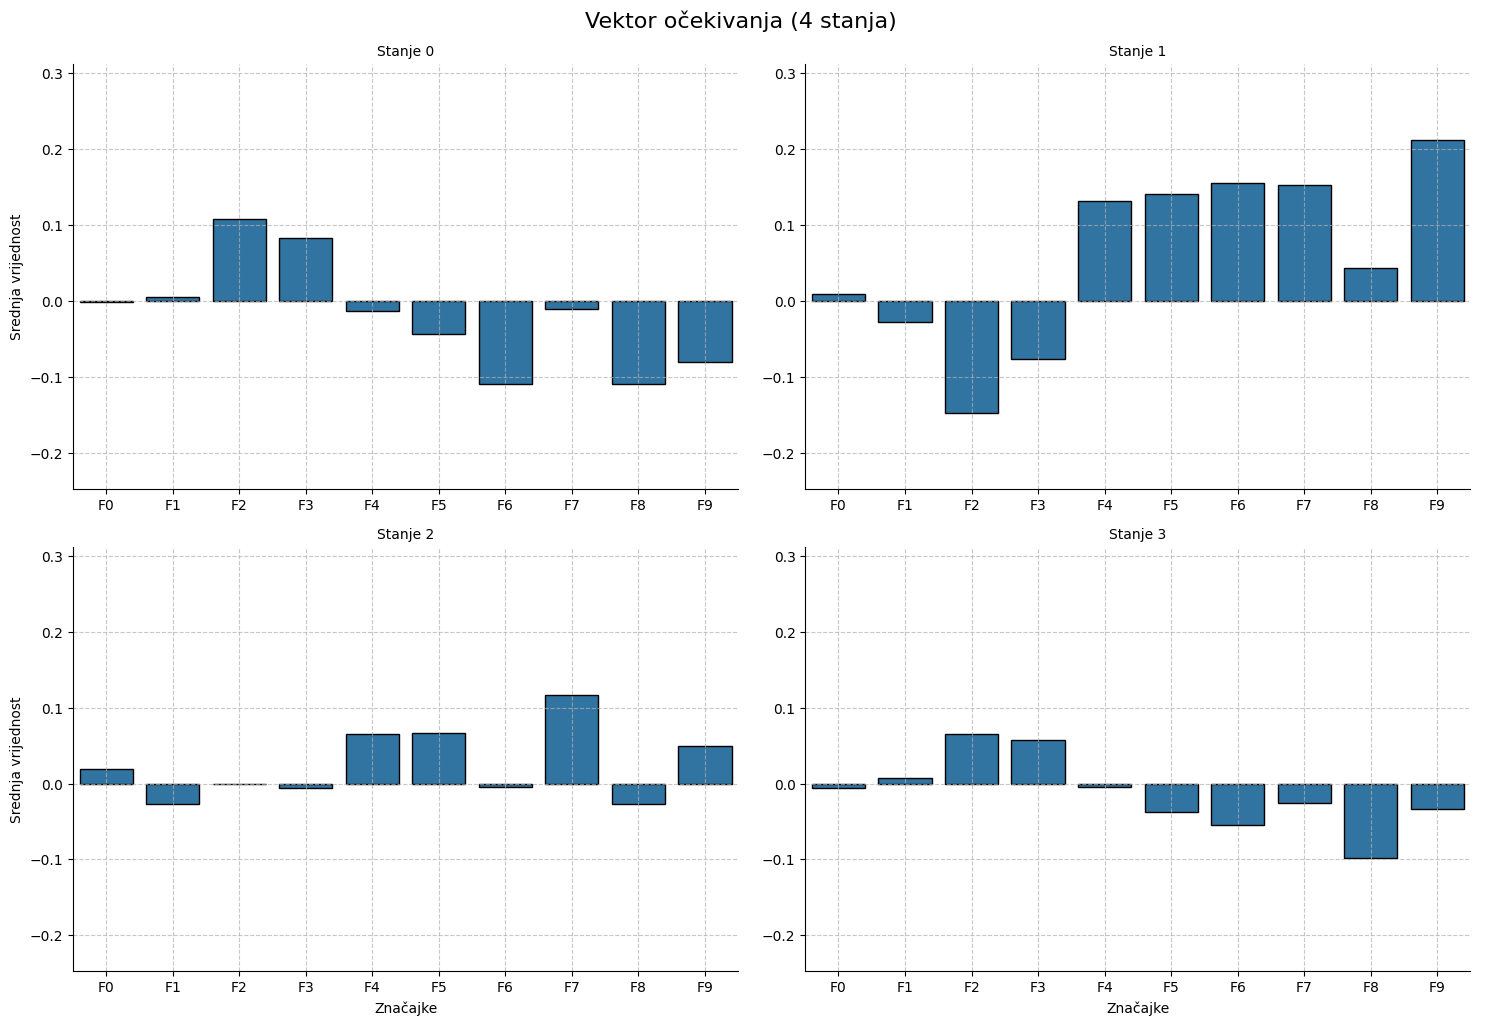

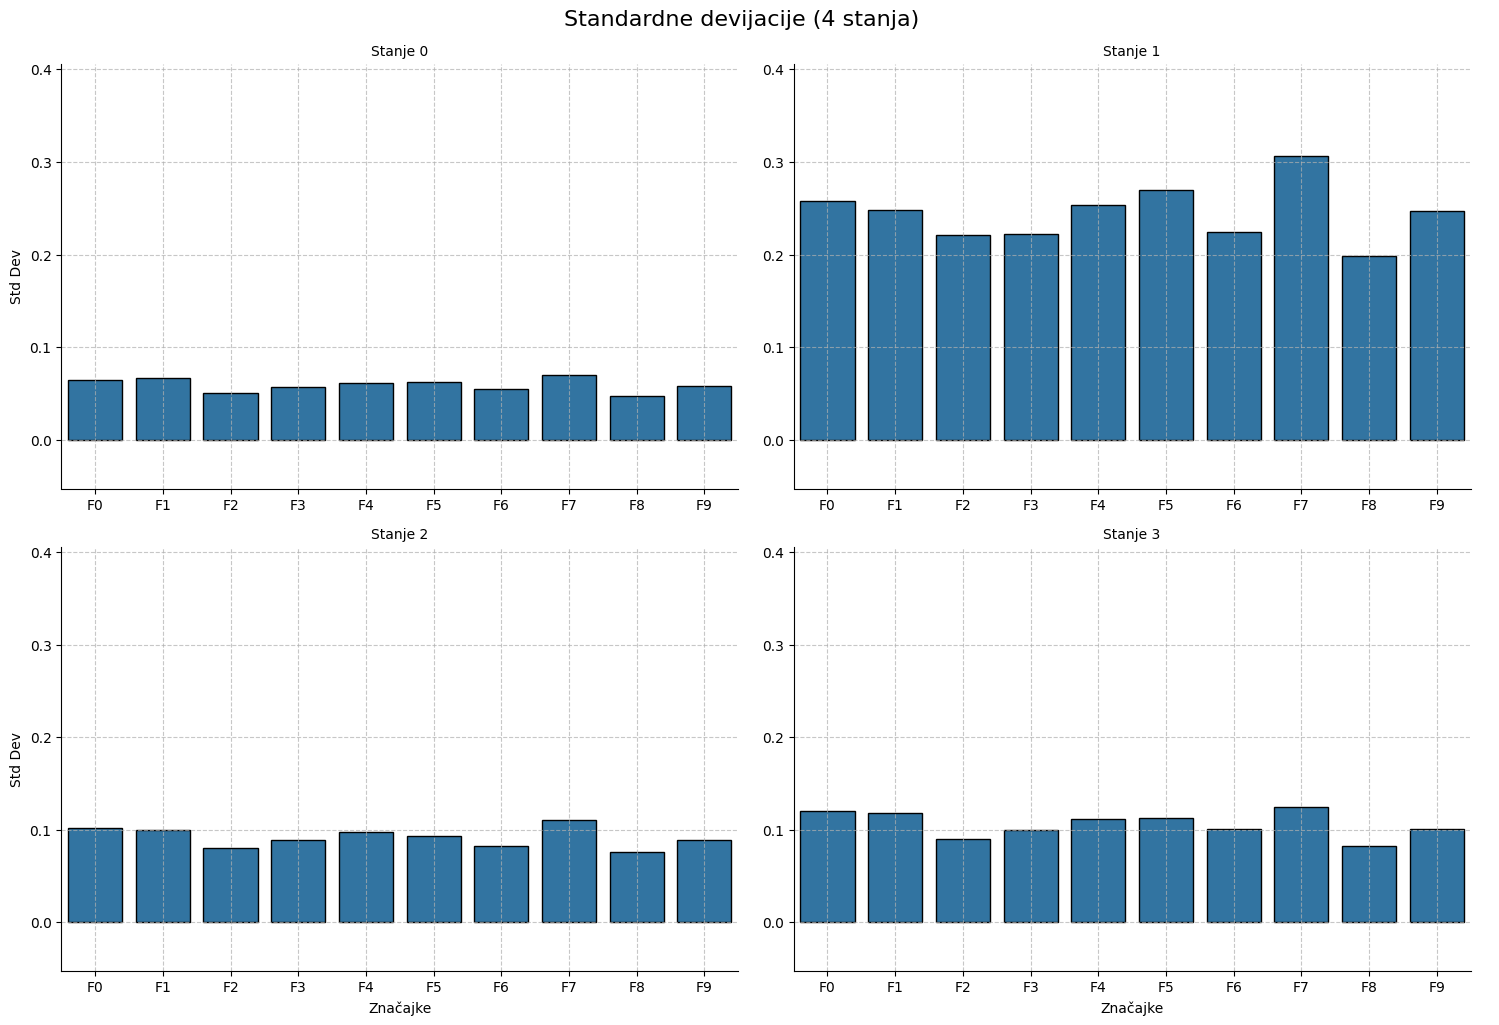

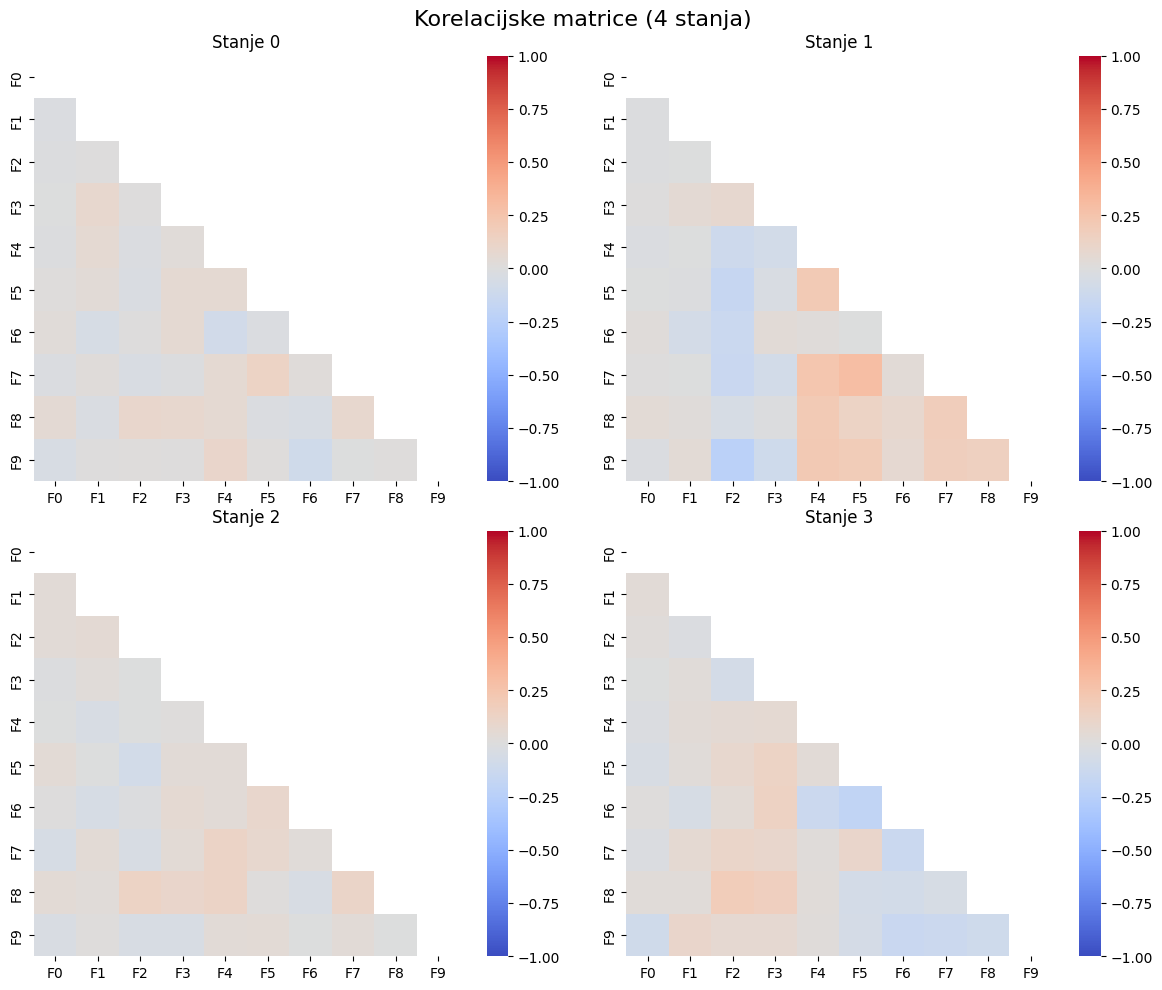

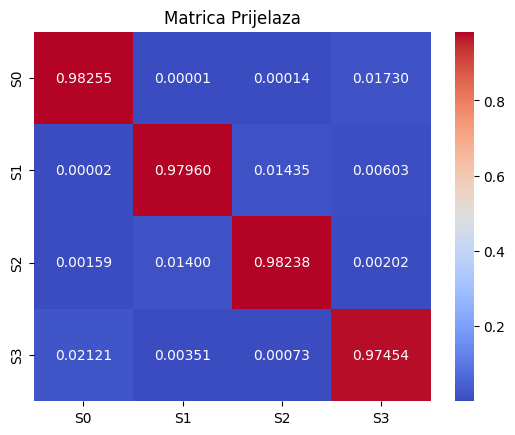

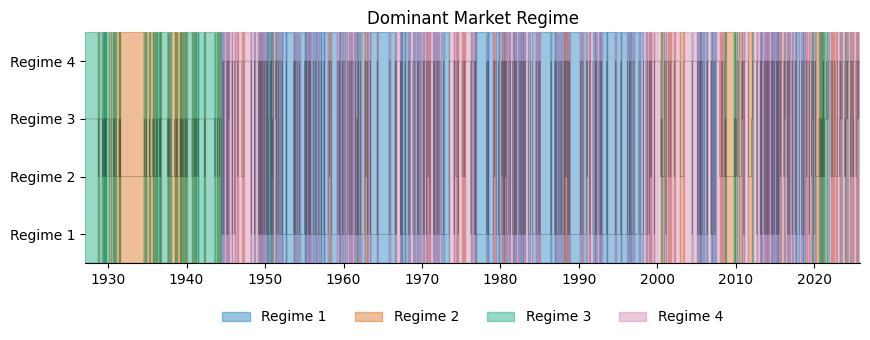

In [42]:
whole_latents = np.concatenate([train_latents, test_latents], axis=0)
state_probs_4 = best_hmm.predict_proba(whole_latents, lengths = len(whole_latents))
run_model_analysis(best_hmm, data, state_probs_4)


In [43]:
# TODO napravi cross validaciju
# from sklearn.model_selection import TimeSeriesSplit

# max_years_lookback = 30

# tscv_y = TimeSeriesSplit(n_splits=30, max_train_size=max_years_lookback*252, test_size=252)
# tscv_q = TimeSeriesSplit(n_splits=20, max_train_size=max_years_lookback*252, test_size=63+50)
# tscv_m = TimeSeriesSplit(n_splits=10, max_train_size=max_years_lookback*252, test_size=21)
